# Cavity Flow: BC vs IBM

This notebook compares two lid-driven cavity setups:

- a boundary-condition reference case with a moving top wall
- an immersed-boundary case where the cavity box and moving lid are imposed with marker IBM

## CPU build and run

For a like-for-like comparison, both cases below are run to the same final time with the same AMR hierarchy (`amr.max_level=0`), the notebook always compares the latest common plotfile name, and the IBM field is cropped back to the lower cavity region before plotting.

CPU build:

```bash
cd /home/haotian/lattice_boltzmann_method/Examples/Cavity_flow
make realclean
make -j28 USE_MPI=FALSE USE_OMP=TRUE DEBUG=FALSE USE_PARTICLES=TRUE
```

Boundary-condition reference:

```bash
OMP_NUM_THREADS=28 ./main2d.gnu.OMP.ex inputs_bc_ref \
  max_step=1250 stop_time=1250 \
  amr.plot_file=out_bc_long/plt \
  amr.plot_int=250
```

IBM cavity:

```bash
OMP_NUM_THREADS=28 ./main2d.gnu.OMP.ex inputs_ibm_box \
  max_step=1250 stop_time=1250 \
  amr.max_level=0 amr.regrid_int=-1 \
  amr.plot_file=out_ibm_long/plt \
  amr.plot_int=250
```

## Validation note

There is no simple closed-form analytical solution for the transient lid-driven cavity here, so the comparison is based on the vorticity field and the standard centerline velocity profiles.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import yt

plt.rcParams["figure.dpi"] = 140
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.2

BC_ROOT = Path("out_bc_long")
IBM_ROOT = Path("out_ibm_long")

def latest_common_plotfile(bc_root, ibm_root):
    bc_plots = sorted(p for p in bc_root.glob("plt*") if p.is_dir())
    ibm_names = {p.name for p in ibm_root.glob("plt*") if p.is_dir()}
    common = [p for p in bc_plots if p.name in ibm_names]
    if not common:
        raise FileNotFoundError(f"No common plotfiles found under {bc_root} and {ibm_root}")
    return common[-1], ibm_root / common[-1].name

def load_midplane_state(plotfile):
    ds = yt.load(str(plotfile))
    base_dims = np.array(ds.domain_dimensions, dtype=int)
    max_lev = int(ds.index.max_level)
    dims = base_dims * (int(ds.refine_by) ** max_lev)
    cg = ds.covering_grid(level=max_lev, left_edge=ds.domain_left_edge, dims=dims, num_ghost_zones=0)

    ux = np.array(cg[("boxlib", "ux")], dtype=float)
    uy = np.array(cg[("boxlib", "uy")], dtype=float)
    vor = np.array(cg[("boxlib", "vor")], dtype=float)
    if ux.ndim == 3:
        k = ux.shape[2] // 2
        ux = ux[:, :, k]
        uy = uy[:, :, k]
        vor = vor[:, :, k]

    lo = np.array(ds.domain_left_edge[:2], dtype=float)
    hi = np.array(ds.domain_right_edge[:2], dtype=float)
    nx, ny = ux.shape
    dx = (hi[0] - lo[0]) / nx
    dy = (hi[1] - lo[1]) / ny
    xc = lo[0] + (np.arange(nx) + 0.5) * dx
    yc = lo[1] + (np.arange(ny) + 0.5) * dy

    return {
        "time": float(ds.current_time),
        "ux": ux,
        "uy": uy,
        "vor": vor,
        "lo": lo,
        "hi": hi,
        "xc": xc,
        "yc": yc,
    }

def crop_ibm_to_cavity(bc, ibm):
    if bc["ux"].shape == ibm["ux"].shape:
        return bc, ibm

    nxb, nyb = bc["ux"].shape
    nxi, nyi = ibm["ux"].shape
    if nxb == nxi and nyi >= nyb:
        ibm = ibm.copy()
        for key in ("ux", "uy", "vor"):
            ibm[key] = ibm[key][:, :nyb]
        ibm["yc"] = ibm["yc"][:nyb]
        ibm["hi"] = np.array([ibm["hi"][0], bc["hi"][1]], dtype=float)
        return bc, ibm

    raise RuntimeError(f"Shape mismatch: BC {bc['ux'].shape}, IBM {ibm['ux'].shape}")

bc_plot, ibm_plot = latest_common_plotfile(BC_ROOT, IBM_ROOT)
bc = load_midplane_state(bc_plot)
ibm = load_midplane_state(ibm_plot)
bc, ibm = crop_ibm_to_cavity(bc, ibm)

print("BC plotfile :", bc_plot)
print("IBM plotfile:", ibm_plot)
print("BC time     :", bc["time"])
print("IBM time    :", ibm["time"])


/home/haotian/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


yt : [INFO     ] 2026-03-28 23:44:55,592 Parameters: current_time              = 10000.0


yt : [INFO     ] 2026-03-28 23:44:55,593 Parameters: domain_dimensions         = [64 64  1]


yt : [INFO     ] 2026-03-28 23:44:55,594 Parameters: domain_left_edge          = [0. 0. 0.]


yt : [INFO     ] 2026-03-28 23:44:55,595 Parameters: domain_right_edge         = [64. 64.  1.]


yt : [INFO     ] 2026-03-28 23:44:55,751 Parameters: current_time              = 10000.0


yt : [INFO     ] 2026-03-28 23:44:55,751 Parameters: domain_dimensions         = [64 96  1]


yt : [INFO     ] 2026-03-28 23:44:55,752 Parameters: domain_left_edge          = [0. 0. 0.]


yt : [INFO     ] 2026-03-28 23:44:55,753 Parameters: domain_right_edge         = [64. 96.  1.]


BC plotfile : out_bc_long/plt10000
IBM plotfile: out_ibm_long/plt10000
BC time     : 10000.0
IBM time    : 10000.0


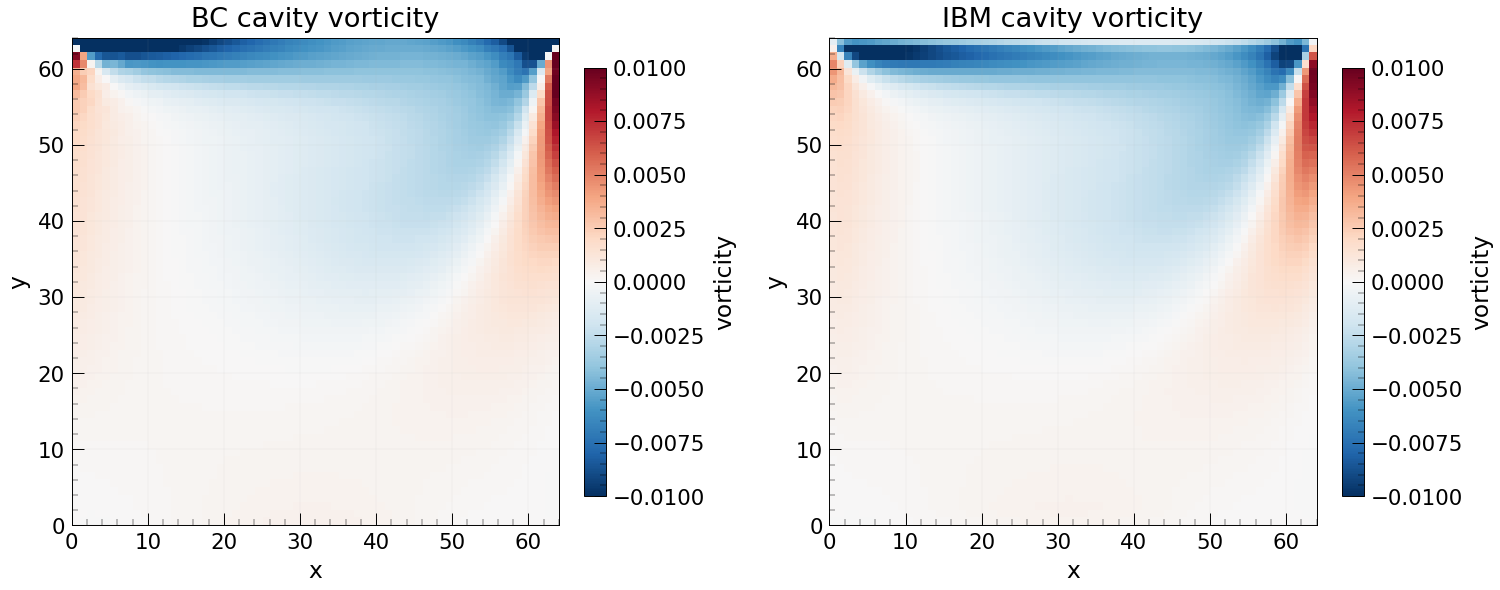

In [2]:
vmax = 1.0e-2

fig, axes = plt.subplots(1, 2, figsize=(10.8, 4.2), constrained_layout=True)
im0 = axes[0].imshow(
    bc["vor"].T,
    origin="lower",
    extent=[bc["lo"][0], bc["hi"][0], bc["lo"][1], bc["hi"][1]],
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[0].set_title("BC cavity vorticity")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
fig.colorbar(im0, ax=axes[0], shrink=0.88, label="vorticity")

im1 = axes[1].imshow(
    ibm["vor"].T,
    origin="lower",
    extent=[ibm["lo"][0], ibm["hi"][0], ibm["lo"][1], ibm["hi"][1]],
    cmap="RdBu_r",
    vmin=-vmax,
    vmax=vmax,
)
axes[1].set_title("IBM cavity vorticity")
axes[1].set_xlabel("x")
axes[1].set_ylabel("y")
fig.colorbar(im1, ax=axes[1], shrink=0.88, label="vorticity")

plt.show()


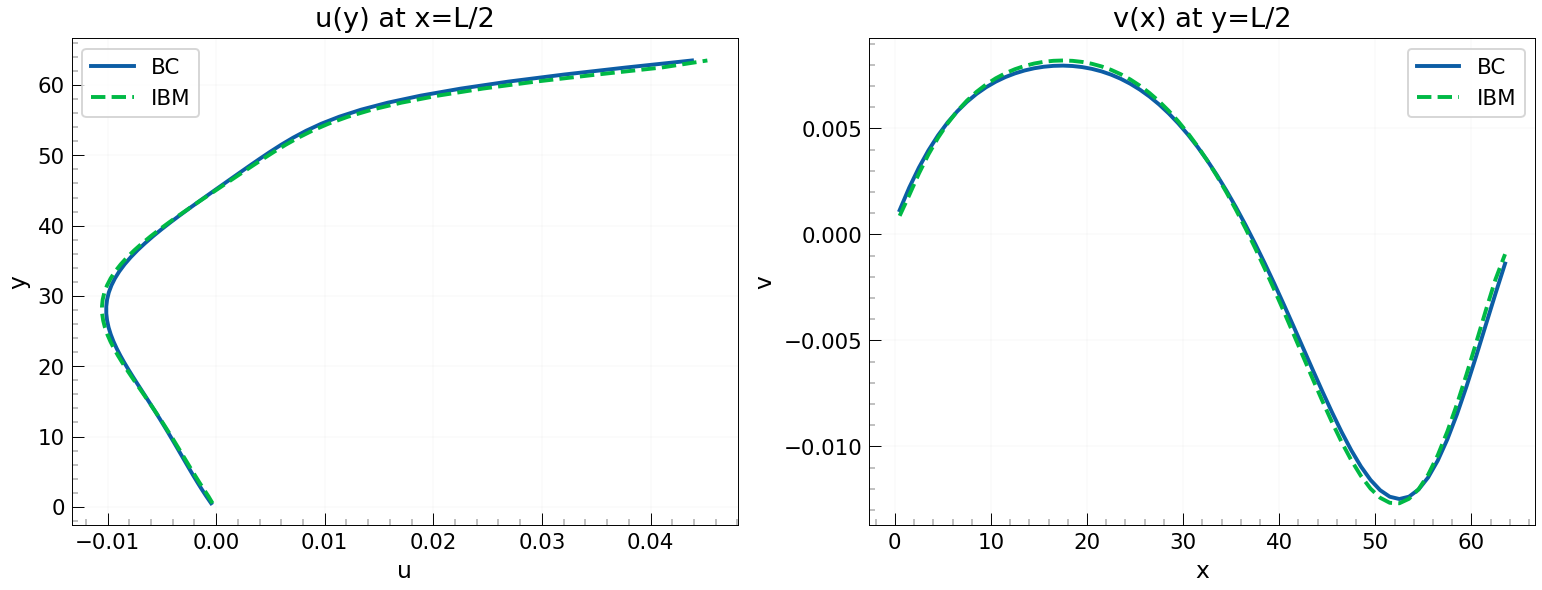

In [3]:
xmid = 0.5 * (bc["lo"][0] + bc["hi"][0])
ymid = 0.5 * (bc["lo"][1] + bc["hi"][1])

ix_bc = int(np.argmin(np.abs(bc["xc"] - xmid)))
ix_ibm = int(np.argmin(np.abs(ibm["xc"] - xmid)))
iy_bc = int(np.argmin(np.abs(bc["yc"] - ymid)))
iy_ibm = int(np.argmin(np.abs(ibm["yc"] - ymid)))

u_bc = bc["ux"][ix_bc, :]
v_bc = bc["uy"][:, iy_bc]
u_ibm = np.interp(bc["yc"], ibm["yc"], ibm["ux"][ix_ibm, :])
v_ibm = np.interp(bc["xc"], ibm["xc"], ibm["uy"][:, iy_ibm])

fig, axes = plt.subplots(1, 2, figsize=(11.0, 4.2), constrained_layout=True)
axes[0].plot(u_bc, bc["yc"], lw=2, label="BC")
axes[0].plot(u_ibm, bc["yc"], "--", lw=2, label="IBM")
axes[0].set_title("u(y) at x=L/2")
axes[0].set_xlabel("u")
axes[0].set_ylabel("y")
axes[0].legend()

axes[1].plot(bc["xc"], v_bc, lw=2, label="BC")
axes[1].plot(bc["xc"], v_ibm, "--", lw=2, label="IBM")
axes[1].set_title("v(x) at y=L/2")
axes[1].set_xlabel("x")
axes[1].set_ylabel("v")
axes[1].legend()
plt.show()
